# Lyric-Based Music Recommendation via Semantic Embedding Learning

## Install requirements

In [1]:
import os
pwd = os.getcwd()
print(f"Present working directory: {pwd}")

Present working directory: /Users/sahanarajashekara/Documents/Projects/music-recommender/music-recommender-ml


In [2]:
pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importing the required Libraries

In [3]:
# import libraries
import os
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer, SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import random
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
import pickle


# Download and initialize required resources for preprocessing
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sahanarajashekara/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sahanarajashekara/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sahanarajashekara/nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sahanarajashekara/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Dataset

### Load the dataset

In [4]:
# Load the song lyrics dataset
file_location = "./spotify_songs.csv"
df = pd.read_csv(file_location, header=0, on_bad_lines='skip')

### Examine the loaded data set
* Fetch information about the columns and data type
* View first few rows of the dataset
* Check if there are any duplicate rows based on track name and artist
* Check if there are any null values in the dataset

In [5]:
# Count duplicates based on track_name and track_artist
print(f"Data info:")
print(df.info())

print("First five rows of the dataset:")
print(df.head())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18454 entries, 0 to 18453
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  18454 non-null  object 
 1   track_name                18454 non-null  object 
 2   track_artist              18454 non-null  object 
 3   lyrics                    18194 non-null  object 
 4   track_popularity          18454 non-null  int64  
 5   track_album_id            18454 non-null  object 
 6   track_album_name          18454 non-null  object 
 7   track_album_release_date  18454 non-null  object 
 8   playlist_name             18454 non-null  object 
 9   playlist_id               18454 non-null  object 
 10  playlist_genre            18454 non-null  object 
 11  playlist_subgenre         18454 non-null  object 
 12  danceability              18454 non-null  float64
 13  energy                    18454 non-null  float64


Importing the 'detect' function from the 'langdetect' library, which detects the language of a given text.

Applying language detection to each entry in the 'lyrics' column of the DataFrame 'df'. For each entry 'x':
- If 'x' is a string, it uses 'detect(x)' to detect the language.
- If 'x' is not a string (e.g., NaN or some other type), it assigns 'unknown' instead.

In [6]:
from langdetect import detect
df['lang'] = df['lyrics'].apply(lambda x: detect(x) if isinstance(x, str) else 'unknown')

In [7]:
# Check for duplicate and null values
num_duplicates = df.duplicated(subset=['track_name', 'track_artist']).sum()
print(f"Number of duplicates:\n {num_duplicates}")
num_na = df.isna().sum()
print(f"Number of null values:\n {num_na}")

Number of duplicates:
 1862
Number of null values:
 track_id                      0
track_name                    0
track_artist                  0
lyrics                      260
track_popularity              0
track_album_id                0
track_album_name              0
track_album_release_date      0
playlist_name                 0
playlist_id                   0
playlist_genre                0
playlist_subgenre             0
danceability                  0
energy                        0
key                           0
loudness                      0
mode                          0
speechiness                   0
acousticness                  0
instrumentalness              0
liveness                      0
valence                       0
tempo                         0
duration_ms                   0
language                    260
lang                          0
dtype: int64


### Data Cleaning
* Remove duplicates entries based on track name and artist
* Remove rows containing null values
* Remove escape characters


In [8]:
# Remove duplicates entries based on track name and artist
df = df.drop_duplicates(subset=['track_name', 'track_artist'], keep='first')
num_duplicates = df.duplicated(subset=['track_name', 'track_artist']).sum()

# Remove rows containing null values
df = df.dropna()
num_na = df.isna().sum()

print(f"Number of duplicates:")
print(num_duplicates)
print(f"Number of null values:")
print(num_na)

# Remove escape characters
def remove_escape_characters(text):
    return text.replace("\r\n", " ")

df['track_name'] = df['track_name'].apply(remove_escape_characters)
df['track_artist'] = df['track_artist'].apply(remove_escape_characters)
df['lyrics'] = df['lyrics'].apply(remove_escape_characters)
df['playlist_name'] = df['playlist_name'].apply(remove_escape_characters)
df['playlist_genre'] = df['playlist_genre'].apply(remove_escape_characters)
df['playlist_subgenre'] = df['playlist_subgenre'].apply(remove_escape_characters)


Number of duplicates:
0
Number of null values:
track_id                    0
track_name                  0
track_artist                0
lyrics                      0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
language                    0
lang                        0
dtype: int64


### Data Pre-processing
* Convert text to lower
* Tokenize text into individual words
* Remove non alpha numeric text
* Detect the language of the text
* Apply language-specific preprocessing:
 * lemmantize and stem the words if English
 * Apply the language-specific stemmer for other supported languages
 * keep only alphanumeric tokens without any stemming or lemmatization if language is not supported

In [9]:
# Define a function to preprocess the lyrics
def convert_to_lower(text):
    return text.lower()
df['track_name'] = df['track_name'].apply(convert_to_lower)
df['track_artist'] = df['track_artist'].apply(convert_to_lower)
df['lyrics'] = df['lyrics'].apply(convert_to_lower)
df['playlist_name'] = df['playlist_name'].apply(convert_to_lower)
df['playlist_genre'] = df['playlist_genre'].apply(convert_to_lower)
df['playlist_subgenre'] = df['playlist_subgenre'].apply(convert_to_lower)

# Define preprocessors
english_stopwords = set(stopwords.words('english'))
english_lemmatizer = WordNetLemmatizer()
english_stemmer = PorterStemmer()

# Add multilingual support
supported_languages = ['english', 'german', 'spanish', 'portuguese', 'italian', 'dutch', 'danish']
multilingual_stemmers = {lang: SnowballStemmer(lang) for lang in supported_languages if lang != 'english'}

def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# Define a function to preprocess the lyrics
def preprocess(text):
    # Check if input is a valid string and not empty or whitespace
    if not isinstance(text, str) or not text.strip():
      return ""

    # Normalize text: remove carriage returns/newlines, lowercase it
    text = text.replace("\r\n", " ").lower()

    # Tokenize the text into words
    tokens = word_tokenize(text)

    # Try to detect the language of the text
    try:
        lang = detect(text)
    except:
        # If detection fails, default to English
        lang = 'english'

    # If the detected language is English
    if lang == 'en':
        # Filter out stopwords and non-alphanumeric tokens
        filtered = [word for word in tokens if word.isalnum() and word not in english_stopwords]
        # Apply stemming followed by lemmatization
        processed = [english_lemmatizer.lemmatize(english_stemmer.stem(word)) for word in filtered]

    # If the language has a stemmer in the 'multilingual_stemmers' dictionary
    elif lang in multilingual_stemmers:
        stemmer = multilingual_stemmers[lang]
        # Only filter non-alphanumeric tokens (no stopword removal)
        filtered = [word for word in tokens if word.isalnum()]
        # Apply the language-specific stemmer
        processed = [stemmer.stem(word) for word in filtered]

    # For unsupported languages
    else:
        # Only basic filtering of non-alphanumeric tokens
        filtered = [word for word in tokens if word.isalnum()]
        processed = filtered

    # Join the processed tokens back into a string and return
    return ' '.join(processed)


df['lyrics'] = df['lyrics'].apply(preprocess)
df['track_artist'] = df['track_artist'].apply(preprocess)

print("Data after pre-processing:")
print(df.head())

Data after pre-processing:
                 track_id                                         track_name  \
0  0017A6SJgTbfQVU2EtsPNo                                           pangarap   
1  004s3t0ONYlzxII9PLgU6z                                       i feel alive   
2  00chLpzhgVjxs1zKC9UScL                                             poison   
3  00cqd6ZsSkLZqGMlQCR0Zo  baby it's cold outside (feat. christina aguilera)   
4  00emjlCv9azBN0fzuuyLqy                                         dumb litty   

     track_artist                                             lyrics  \
0   barbie cradle  minsan pa nang ako y napalingon hindi ko alam ...   
1   steadi rollin  tree sing wind sky blue angel smile saw lone b...   
2  bell biv devoe  na yeah spyderman freez full effect readi ron ...   
3     ceelo green  realli ca stay babi cold outsid got go away ba...   
4            kard  get busi keep turn 모두 다 여긴 wit 넌 바른 척하는 crimin...   

   track_popularity          track_album_id  \
0           

### Data Exploration and Visualization
Visualize the distribution of playlist genres and subgenres using count plots
Analyze average audio features by genre with bar plots
Use t-SNE to reduce audio feature dimensions and visualize song clusters based on their genre


['rock' 'r&b' 'pop' 'edm' 'latin' 'rap']


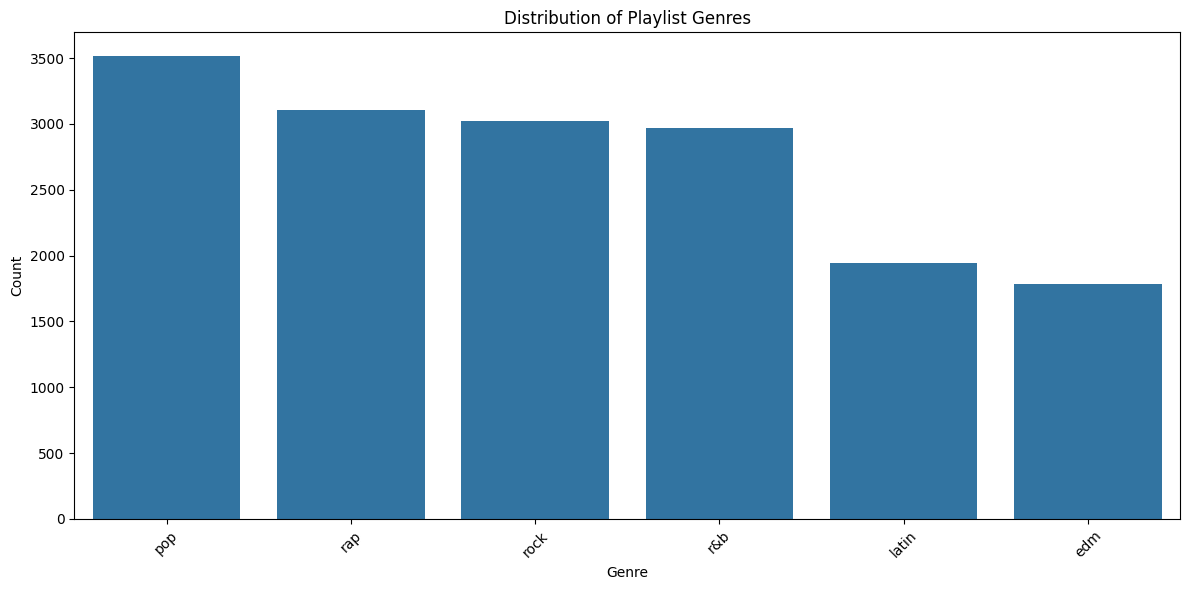

In [10]:

# Print the unique genre values
print(df['playlist_genre'].unique())

# Plot genre using count plots
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='playlist_genre', order=df['playlist_genre'].value_counts().index)
plt.title('Distribution of Playlist Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


['classic rock' 'hard rock' 'new jack swing' 'neo soul' 'dance pop'
 'urban contemporary' 'big room' 'hip pop' 'latin pop' 'indie poptimism'
 'gangster rap' 'album rock' 'post-teen pop' 'trap' 'latin hip hop'
 'southern hip hop' 'tropical' 'electropop' 'progressive electro house'
 'pop edm' 'reggaeton' 'hip hop' 'permanent wave' 'electro house']


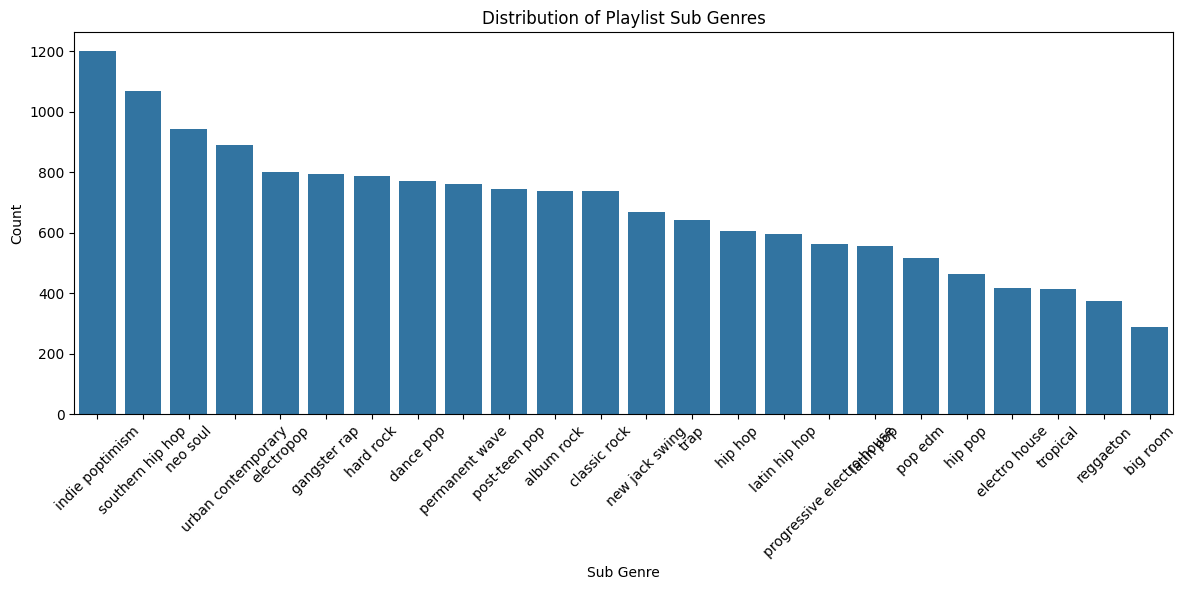

In [11]:
# Print the unique sub genre values
print(df['playlist_subgenre'].unique())

# Plot sub genre using count plots
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='playlist_subgenre', order=df['playlist_subgenre'].value_counts().index)
plt.title('Distribution of Playlist Sub Genres')
plt.xlabel('Sub Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

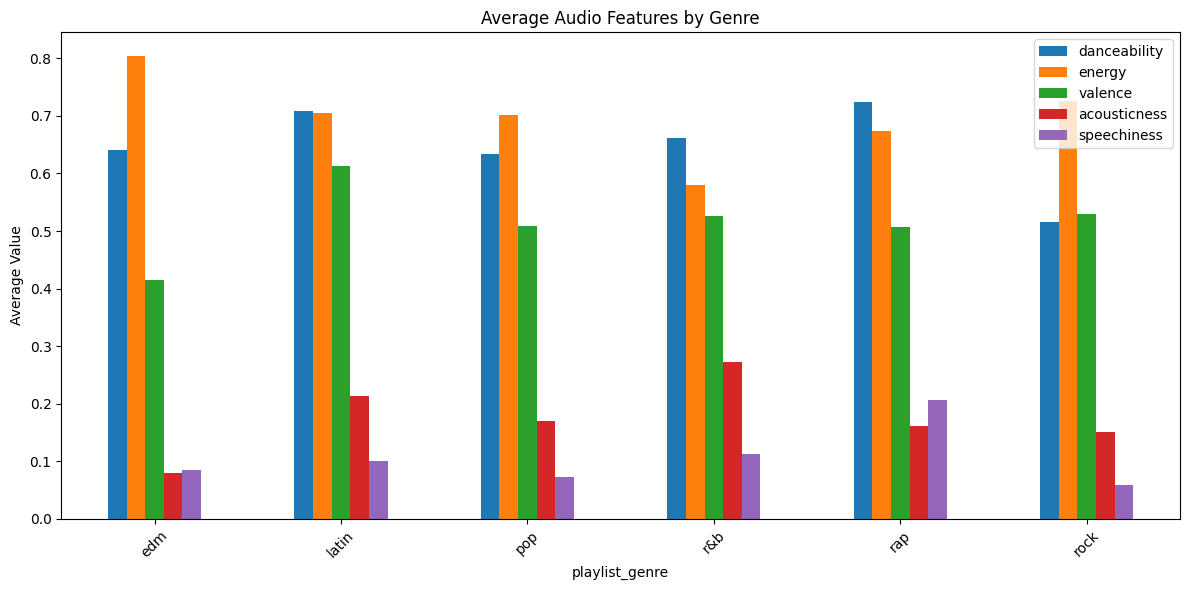

In [12]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
df.groupby('playlist_genre')[audio_features].mean().plot(kind='bar', figsize=(12,6))
plt.title("Average Audio Features by Genre")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


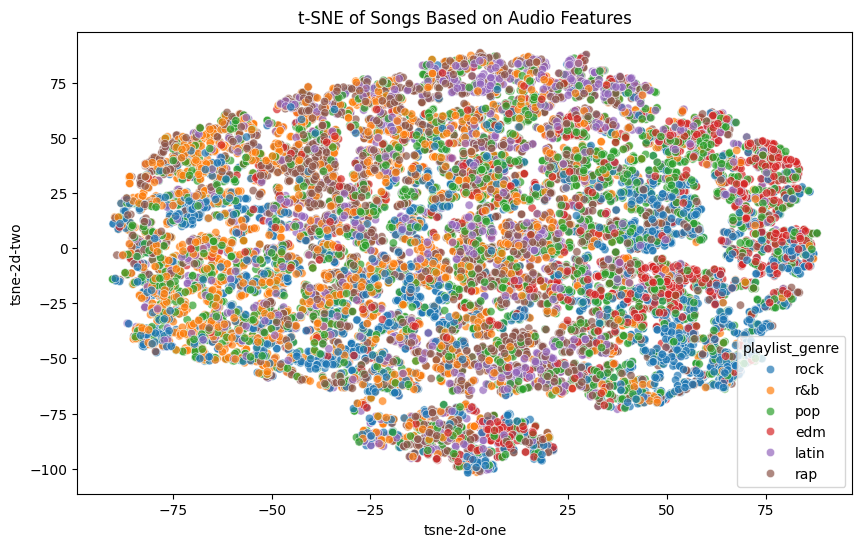

In [13]:
# Define the list of audio features to use for t-SNE
audio_features = ['danceability', 'energy', 'acousticness', 'tempo', 'liveness', 'loudness']
# Standardizing the audio features using StandardScaler
scaled_features = StandardScaler().fit_transform(df[audio_features])
# Applying t-SNE to reduce the dimensionality of the scaled audio features to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

# Creating a scatter plot to visualize the 2D t-SNE results
df['tsne-2d-one'] = tsne_results[:, 0]
df['tsne-2d-two'] = tsne_results[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="playlist_genre", data=df, palette="tab10", alpha=0.7)
plt.title("t-SNE of Songs Based on Audio Features")
plt.show()


## Model

### Pre-define inputs

In [14]:
top_n = 10
song = "dumb litty"
song_input = song.lower()

### Audio Features
* Normalize Audio Features
* Select relevant audio features and normalize them to a range of [0, 1] for consistent scaling across features

In [15]:
# Select relevant audio features
audio_features = ['danceability', 'energy', 'acousticness', 'tempo', 'liveness', 'loudness']
audio_data = df[audio_features].values

# Normalize audio features to [0, 1]
scaler = MinMaxScaler()
audio_data_scaled = scaler.fit_transform(audio_data)


### Nearest Neighbors Model (Audio Features)
Fit a Nearest Neighbors model only on the normalized audio features using cosine similarity

In [16]:
# Initialize a NearestNeighbors model for audio features and train the model
nn_audio = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
nn_audio.fit(audio_data_scaled)

,n_neighbors,11
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


### Get Audio Recommendations
* Find the top-N similar songs based on their audio features using the Nearest Neighbors model
* Return the recommendations with track name, artist, genre, and similarity score

In [17]:
def get_audio_recommendations(song_input, nn_model, scaled_audio_data, top_n):
    # Find the index of the input song in the dataframe
    song_idx = df[df['track_name'] == song_input].index[0]

    # Get the vector of the song
    song_vector = scaled_audio_data[song_idx].reshape(1, -1)

    # Find the nearest neighbors
    distances, indices = nn_model.kneighbors(song_vector)

    recommendations = []
    for idx, dist in zip(indices[0][1:], distances[0][1:]):  # Skip the first one (it's the song itself)
        rec = {
            'track_name': df.iloc[idx]['track_name'],
            'track_artist': df.iloc[idx]['track_artist'],
            'genre': df.iloc[idx]['playlist_genre'],
            'similarity': 1 - dist  # Since cosine distance, similarity = 1 - distance
        }
        recommendations.append(rec)

    return recommendations

In [18]:
# Get the recommendations for the input song
audio_recs = get_audio_recommendations(song_input, nn_audio, audio_data_scaled, top_n)

# Print results
for i, rec in enumerate(audio_recs, 1):
    print(f"{i}. {rec['track_name']} by {rec['track_artist']} (Genre: {rec['genre']}, Similarity: {rec['similarity']})")

1. fallin' (feat. twan ray) by lulleaux (Genre: edm, Similarity: 0.9998320944503265)
2. oh baby by seizo (Genre: latin, Similarity: 0.9997846934694217)
3. don't leave me alone (feat. anne-marie) - edx's indian summer remix by david guetta (Genre: pop, Similarity: 0.9997474135567376)
4. idol by bts (Genre: pop, Similarity: 0.9997469442101313)
5. we found love (feat. ashibah) by nora en pure (Genre: edm, Similarity: 0.9997385294120589)
6. fireproof - embody remix by coleman hell (Genre: latin, Similarity: 0.9997376142709363)
7. i'm not alright - frank walker remix by loud luxury (Genre: edm, Similarity: 0.9997267767552882)
8. teenage dream by katy perry (Genre: latin, Similarity: 0.9997189226858504)
9. came here for love by sigala (Genre: pop, Similarity: 0.9997082837061838)
10. illuminate by aint (Genre: latin, Similarity: 0.9996763249122909)


### TF-IDF Vectorization
* Convert lyrics into a TF-IDF representation
* Generate a combined TF-IDF representation of lyrics and artist, where the artist name is repeated (weighted) to emphasize its influence on the vectorization

In [19]:
# Convert text data to TF-IDF representation
vectorizer = TfidfVectorizer()
lyrics_tfidf = vectorizer.fit_transform(df['lyrics'])

lyrics_tfidf_sparse = csr_matrix(lyrics_tfidf)

def combine_artist_and_lyrics(row):
    artist = row['track_artist'] #artist_name
    lyrics = row['lyrics']
    return (artist + ' ') * 3 + lyrics  # artist weight = 3x # trial and error and decide weightage

df['artist_lyrics'] = df.apply(combine_artist_and_lyrics, axis=1)
lyrics_artist_tfidf = vectorizer.fit_transform(df['artist_lyrics'])

lyrics_artist_tfidf_sparse = csr_matrix(lyrics_artist_tfidf)

### Nearest Neighbors Model (TF-IDF)
* Fit Nearest Neighbors model on TF-IDF of lyrics
* Fit Nearest Neighbors model on TF-IDF of artist and lyrics combined

In [20]:
# Initialize a NearestNeighbors model for TF-IDF lyrics features.
nn_tfidf_lyrics = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
nn_tfidf_lyrics.fit(lyrics_tfidf_sparse)

# Initialize a NearestNeighbors model for TF-IDF lyrics + Artist features.
nn_tfidf_lyrics_artist = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
nn_tfidf_lyrics_artist.fit(lyrics_artist_tfidf_sparse)

,n_neighbors,11
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


### Get Recommendations(TF-IDF)
* Use the model to find the most similar songs based on cosine similarity

* Return top N similar songs with track name, artist, genre and similarity score

In [21]:
def get_tfidf_recommendations(song_title, model, song_vectors, top_n=10):
    if song_title not in df['track_name'].values:
        return "Song not found in dataset."

    # Get index of the input song
    idx = df[df['track_name'] == song_title].index[0]

    # Get its vector
    song_vector = song_vectors[idx]

    # Get top_n + 1 neighbors (including itself)
    distances, indices = model.kneighbors(song_vector, n_neighbors=top_n+1)

    # Extract actual neighbors (excluding the input song)
    similar_indices = indices[0][1:]
    similar_distances = distances[0][1:]

    recommendations = []

    for i, dist in zip(similar_indices, similar_distances):
        similarity = round(1 - dist, 4)  # Convert distance to similarity
        track = df.iloc[i]
        artist = track['track_artist']

        recommendations.append({
            'track_name': track['track_name'],
            'artist_name': artist,
            "genre": track['playlist_genre'],
            "sub_genre": track['playlist_subgenre'],
            "playlist_name": track['playlist_name'],
            'similarity_score': similarity
        })

    return recommendations


In [22]:
# Get the recommendations for the input song
tfidf_lyrics_recs = get_tfidf_recommendations(song_input, nn_tfidf_lyrics, lyrics_tfidf_sparse,  top_n)
# Display the recommendations
for i, rec in enumerate(tfidf_lyrics_recs, start=1):
    print(f"{i}. {rec['track_name']} by {rec['artist_name']} (Genre: {rec['genre']}, Sub Genre: {rec['sub_genre']},Similarity: {rec['similarity_score']})")

1. perfume by annella (Genre: edm, Sub Genre: electro house,Similarity: 0.5934)
2. litty (feat. tory lanez) by meek mill (Genre: rap, Sub Genre: gangster rap,Similarity: 0.4522)
3. young dumb & broke by khalid (Genre: pop, Sub Genre: post-teen pop,Similarity: 0.4276)
4. numb numb by juvenile (Genre: rap, Sub Genre: southern hip hop,Similarity: 0.344)
5. silly girl by chloe moriondo (Genre: pop, Sub Genre: indie poptimism,Similarity: 0.3257)
6. stupid in love by rihanna (Genre: latin, Sub Genre: latin hip hop,Similarity: 0.274)
7. whiskey in the jar by thin lizzi (Genre: rock, Sub Genre: hard rock,Similarity: 0.2679)
8. knockin' by angel grant (Genre: r&b, Sub Genre: neo soul,Similarity: 0.2553)
9. young like this - hedegaard remix by hugo helmig (Genre: edm, Sub Genre: progressive electro house,Similarity: 0.2359)
10. doubt by charlott day wilson (Genre: r&b, Sub Genre: neo soul,Similarity: 0.2127)


In [23]:
# Get the recommendations for the input song
tfidf_artist_lyrics_recs = get_tfidf_recommendations(song_input, nn_tfidf_lyrics_artist, lyrics_artist_tfidf_sparse, top_n=10)
# Display the recommendations
for i, rec in enumerate(tfidf_artist_lyrics_recs, start=1):
    print(f"{i}. {rec['track_name']} by {rec['artist_name']} (Genre: {rec['genre']},Similarity: {rec['similarity_score']})")

1. perfume by annella (Genre: edm,Similarity: 0.5877)
2. litty (feat. tory lanez) by meek mill (Genre: rap,Similarity: 0.4487)
3. young dumb & broke by khalid (Genre: pop,Similarity: 0.4278)
4. numb numb by juvenile (Genre: rap,Similarity: 0.3382)
5. silly girl by chloe moriondo (Genre: pop,Similarity: 0.2891)
6. stupid in love by rihanna (Genre: latin,Similarity: 0.2679)
7. whiskey in the jar by thin lizzi (Genre: rock,Similarity: 0.2567)
8. knockin' by angel grant (Genre: r&b,Similarity: 0.2456)
9. young like this - hedegaard remix by hugo helmig (Genre: edm,Similarity: 0.2216)
10. doubt by charlott day wilson (Genre: r&b,Similarity: 0.1948)


### Generate SBERT Embeddings
* Use the pre-trained SBERT model all-MiniLM-L6-v2 to convert lyrics and combined artist-lyrics text into dense vector embeddings

* This step captures semantic meaning of the text in fixed-size vectors for similarity comparisons and downstream tasks

In [24]:
# Load SBERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all lyrics into embeddings
lyrics_embeddings = model.encode(df['lyrics'].tolist(), show_progress_bar=True, convert_to_numpy=True)
lyrics_artist_embeddings = model.encode(df['artist_lyrics'].tolist(), show_progress_bar=True, convert_to_numpy=True)

Batches: 100%|████████████████████████████████| 511/511 [01:19<00:00,  6.44it/s]


### Nearest Neighbors Model (SBERT)
* Fit Nearest Neighbors model on SBERT embeddings of lyrics

* Fit Nearest Neighbors model on SBERT embeddings of artist and lyrics combined

In [25]:
# Initialize a Nearest Neighbors model using cosine distance for BERT-based lyrics embeddings
nn_bert_lyrics = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
# Fit the model with lyrics-only BERT embeddings
nn_bert_lyrics.fit(lyrics_embeddings)

# Initialize a Nearest Neighbors model using cosine distance for BERT-based lyrics +artist embeddings
nn_bert_lyrics_artist = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
# Fit the model with lyrics + artist BERT embeddings
nn_bert_lyrics_artist.fit(lyrics_artist_embeddings)

,n_neighbors,11
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


### Generate Recommendations using SBERT
* Use the model to find the most similar songs based on cosine similarity of SBERT embeddings

* Return top N similar songs with track name, artist, genre and similarity score

In [26]:
def get_bert_recommendations(song_title, model, embeddings, top_n=10):
    # Check if the input song title exists in the DataFrame
    if song_title not in df['track_name'].values:
        return "Song not found in dataset."
    # Get the index of the song in the DataFrame
    idx = df[df['track_name'] == song_title].index[0]

    # Extract the BERT embedding for the input song and reshape it for the model
    query_embedding = embeddings[idx].reshape(1, -1)

    # Use the provided NearestNeighbors model to find the top_n most similar songs
    distances, indices = model.kneighbors(query_embedding, n_neighbors=top_n+1)

    recommendations = []
    # Skip the first result (the song itself) and collect the rest
    for i, (index, distance) in enumerate(zip(indices[0][1:], distances[0][1:]), 1):
        track = df.iloc[index]
        # Convert cosine distance to cosine similarity
        similarity = 1 - distance

        # Store relevant details of the recommended song
        recommendations.append({
            "track_name": track['track_name'],
            "track_artist": track['track_artist'],
            "similarity": similarity,
            "genre": track['playlist_genre']
        })
    return recommendations


In [27]:
# Get the recommendations for the input song
bert_lyrics_recs = get_bert_recommendations(song_input, nn_bert_lyrics, lyrics_embeddings,  top_n=10)
# Display the recommendations
for i, rec in enumerate(bert_lyrics_recs, 1):
    print(f"{i}. {rec['track_name']} by {rec['track_artist']} (Genre: {rec['genre']}, Similarity: {rec['similarity']})")

1. ah yeah by winner (Genre: pop, Similarity: 0.6993691325187683)
2. energetic (prequel remix) by wan na one (Genre: edm, Similarity: 0.6732220649719238)
3. siren by sunmi (Genre: pop, Similarity: 0.6673133373260498)
4. good boy by gd x taeyang (Genre: edm, Similarity: 0.6672165393829346)
5. forever young by blackpink (Genre: pop, Similarity: 0.6624345779418945)
6. me & you by exid (Genre: pop, Similarity: 0.6493447422981262)
7. forever love by youngjae (Genre: pop, Similarity: 0.6464974880218506)
8. bad dracula by red velvet (Genre: edm, Similarity: 0.6411926746368408)
9. psycho by red velvet (Genre: latin, Similarity: 0.6403051614761353)
10. starry night by mamamoo (Genre: pop, Similarity: 0.6399413347244263)


In [28]:
# Get the recommendations for the input song
bert_lyrics_artist_recs = get_bert_recommendations(song_input, nn_bert_lyrics_artist, lyrics_artist_embeddings,  top_n=10)
# Display the recommendations
for i, rec in enumerate(bert_lyrics_artist_recs, 1):
    print(f"{i}. {rec['track_name']} by {rec['track_artist']} (Genre: {rec['genre']}, Similarity: {rec['similarity']})")

1. push & pull by kard (Genre: edm, Similarity: 0.679702877998352)
2. bomb bomb by kard (Genre: pop, Similarity: 0.634945273399353)
3. ah yeah by winner (Genre: pop, Similarity: 0.6083097457885742)
4. good boy by gd x taeyang (Genre: edm, Similarity: 0.5974740386009216)
5. energetic (prequel remix) by wan na one (Genre: edm, Similarity: 0.5826969146728516)
6. forever young by blackpink (Genre: pop, Similarity: 0.5787859559059143)
7. forever love by youngjae (Genre: pop, Similarity: 0.571776807308197)
8. boy with luv (feat. halsey) by bts (Genre: pop, Similarity: 0.560021162033081)
9. not that type by gugudan (Genre: pop, Similarity: 0.5574356913566589)
10. really by blackpink (Genre: edm, Similarity: 0.5574177503585815)


In [29]:
# Combine lyrics embeddings with audio features for each song.
lyrics_audio_embeddings = np.hstack((lyrics_embeddings, audio_data_scaled))
# Combine lyrics + artist embeddings with audio features for each song.
lyrics_artist_audio_embeddings = np.hstack((lyrics_artist_embeddings, audio_data_scaled))

In [30]:
# Create a NearestNeighbors model for the lyrics + audio embedding space.
nn_bert_lyrics_audio = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
nn_bert_lyrics_audio.fit(lyrics_audio_embeddings)

# Create a NearestNeighbors model for the lyrics + artist audio embedding space.
nn_bert_lyrics_artist_audio = NearestNeighbors(n_neighbors=top_n+1, metric='cosine', algorithm='brute')
nn_bert_lyrics_artist_audio.fit(lyrics_artist_audio_embeddings)

,n_neighbors,11
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [31]:
# Get the recommendations for the input song
bert_lyrics_audio_recs = get_bert_recommendations(song_input, nn_bert_lyrics_audio, lyrics_audio_embeddings, top_n)

# Display the recommendations
for i, rec in enumerate(bert_lyrics_audio_recs, 1):
    print(f"{i}. {rec['track_name']} by {rec['track_artist']} (Genre: {rec['genre']}, Similarity: {rec['similarity']})")


1. siren by sunmi (Genre: pop, Similarity: 0.8915876287389728)
2. good boy by gd x taeyang (Genre: edm, Similarity: 0.8904586202054814)
3. me & you by exid (Genre: pop, Similarity: 0.8904060745844221)
4. forever young by blackpink (Genre: pop, Similarity: 0.8899534417420605)
5. ah yeah by winner (Genre: pop, Similarity: 0.8866233802036253)
6. not that type by gugudan (Genre: pop, Similarity: 0.8861351022904621)
7. forever love by youngjae (Genre: pop, Similarity: 0.885370457190545)
8. me by clc (Genre: pop, Similarity: 0.8851959951415883)
9. yes or yes by twice (Genre: pop, Similarity: 0.8821362195335256)
10. how's this by hyuna (Genre: edm, Similarity: 0.8821163342495325)


In [32]:
# Get the recommendations for the input song
bert_lyrics_artist_audio_recs = get_bert_recommendations(song_input, nn_bert_lyrics_artist_audio, lyrics_artist_audio_embeddings, top_n)

# Display the recommendations
for i, rec in enumerate(bert_lyrics_artist_audio_recs, 1):
    print(f"{i}. {rec['track_name']} by {rec['track_artist']} (Genre: {rec['genre']}, Similarity: {rec['similarity']})")


1. push & pull by kard (Genre: edm, Similarity: 0.8906852211597629)
2. bomb bomb by kard (Genre: pop, Similarity: 0.8769965419871276)
3. good boy by gd x taeyang (Genre: edm, Similarity: 0.8687418036822597)
4. not that type by gugudan (Genre: pop, Similarity: 0.866051514539032)
5. really by blackpink (Genre: edm, Similarity: 0.8659718265612877)
6. forever young by blackpink (Genre: pop, Similarity: 0.8646390445907933)
7. enough by got7 (Genre: edm, Similarity: 0.8632982995482138)
8. how's this by hyuna (Genre: edm, Similarity: 0.8619693245627722)
9. forever love by youngjae (Genre: pop, Similarity: 0.8616399092272492)
10. me by clc (Genre: pop, Similarity: 0.8592877296796435)


### t-SNE Visualization with Audio + Lyrics Features
Reduce the dimensionality of combined audio and lyrics embeddings using t-SNE for visualization
Plot the songs in 2D space and color them by their genre to observe any clustering patterns

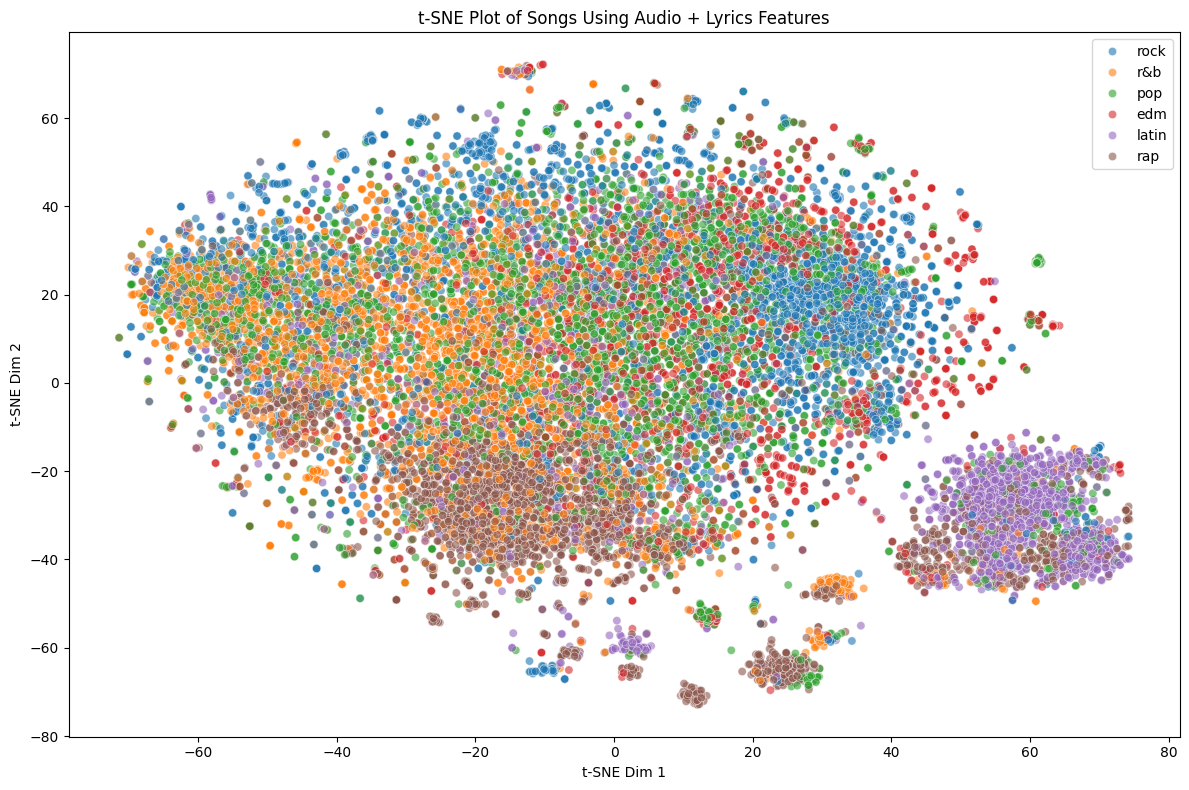

In [34]:
# Initialize t-SNE with 2D output, specific perplexity and iterations for better clustering
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
# Apply t-SNE on combined embeddings (lyrics + artist + audio)
tsne_results = tsne.fit_transform(lyrics_artist_audio_embeddings)

# Add t-SNE results as new columns to the DataFrame
df['tsne_combined_1'] = tsne_results[:, 0]
df['tsne_combined_2'] = tsne_results[:, 1]

# Plotting the 2D t-SNE scatter plot colored by genre
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_combined_1',
    y='tsne_combined_2',
    hue='playlist_genre',
    data=df,
    alpha=0.6,
    palette='tab10'
)
plt.title('t-SNE Plot of Songs Using Audio + Lyrics Features')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend(loc='best', fontsize='medium')
plt.tight_layout()
plt.show()


## **Evaluation**

### Sample Songs for Evaluation
* Filter out songs that have valid embeddings and sample a subset for evaluation
* This ensures we are working with songs that have corresponding embeddings for recommendation

In [35]:
# First, ensure we only sample from songs that have embeddings
def get_valid_song_titles(df, embeddings):
    # Get only song titles that have valid indices in the embeddings array
    valid_indices = [idx for idx in df.index if idx < len(embeddings)]
    valid_df = df.loc[valid_indices]
    return valid_df['track_name'].unique().tolist()

# Sample only from valid songs
random.seed(10)
valid_titles = get_valid_song_titles(df, lyrics_artist_audio_embeddings,)
sampled_titles = random.sample(valid_titles, min(100, len(valid_titles)))
print(f"Sampled {len(sampled_titles)} songs for evaluation")

Sampled 100 songs for evaluation


### Evaluate Recommendation Precision and Recall
* Evaluate the precision and recall of various recommendation models (TF-IDF, BERT, Audio) by calculating the proportion of true positive recommendations that match the input genre.
* This is done for multiple models: TF-IDF (lyrics only and lyrics + artist), BERT (lyrics only and lyrics + artist), BERT (lyrics + artist + audio), and Audio features.

In [36]:
def get_true_positive(recommendations, input_genre):
    return sum(1 for rec in recommendations if input_genre in rec['genre'].split(','))

def get_candidate_genre_count(song_title, func, model, data, input_genre, k=100):
    # Get a larger candidate pool
    candidates = func(song_title, model, data, top_n=k)
    return sum(1 for rec in candidates if rec['genre'] == input_genre)

# Initialize precision and recall lists
models = ["tfidf_lyrics", "tfidf_lyrics_artist", "bert_lyrics",
          "bert_lyrics_artist", "bert_lyrics_artist_audio", "audio"]

precision_scores = {model: [] for model in models}
recall_scores = {model: [] for model in models}

def evaluate_recommendations(song_titles):
    for song_title in song_titles:
        row = df[df['track_name'] == song_title]
        if row.empty:
            print(f"Warning: Song title '{song_title}' not found.")
            continue
        input_genre = row.iloc[0]['playlist_genre']

        # Each model evaluation
        model_configs = [
            ("tfidf_lyrics", get_tfidf_recommendations, nn_tfidf_lyrics, lyrics_tfidf_sparse),
            ("tfidf_lyrics_artist", get_tfidf_recommendations, nn_tfidf_lyrics_artist, lyrics_artist_tfidf_sparse),
            ("bert_lyrics", get_bert_recommendations, nn_bert_lyrics, lyrics_embeddings),
            ("bert_lyrics_artist", get_bert_recommendations, nn_bert_lyrics_artist, lyrics_artist_embeddings),
            ("bert_lyrics_artist_audio", get_bert_recommendations, nn_bert_lyrics_artist_audio, lyrics_artist_audio_embeddings),
            ("audio", get_audio_recommendations, nn_audio, audio_data_scaled),
        ]

        for model_name, func, model, data in model_configs:
            recs_top_n = func(song_title, model, data, top_n)
            true_pos = get_true_positive(recs_top_n, input_genre)

            # New recall denominator: relevant songs among top-100 nearest neighbors
            genre_count_in_candidates = get_candidate_genre_count(song_title, func, model, data, input_genre, k=100)
            recall = true_pos / genre_count_in_candidates if genre_count_in_candidates > 0 else 0

            precision_scores[model_name].append(true_pos / top_n)
            recall_scores[model_name].append(recall)

evaluate_recommendations(sampled_titles)

# Print average precision and recall
for model in models:
    avg_precision = np.mean(precision_scores[model])
    avg_recall = np.mean(recall_scores[model])
    print(f"Model: {model}")
    print(f"  Average Precision: {avg_precision:.4f}")
    print(f"  Average Recall: {avg_recall:.4f}\n")


Model: tfidf_lyrics
  Average Precision: 0.1830
  Average Recall: 0.0904

Model: tfidf_lyrics_artist
  Average Precision: 0.1880
  Average Recall: 0.0910

Model: bert_lyrics
  Average Precision: 0.2370
  Average Recall: 0.1143

Model: bert_lyrics_artist
  Average Precision: 0.2190
  Average Recall: 0.0927

Model: bert_lyrics_artist_audio
  Average Precision: 0.1710
  Average Recall: 0.0777

Model: audio
  Average Precision: 0.1810
  Average Recall: 0.7100



### Display Precision and Recall Summary
Generate a table summarizing the average precision and average recall for different recommendation methods: Audio, TF-IDF (Lyrics), TF-IDF (Lyrics + Artist), BERT (Lyrics), BERT (Lyrics + Artist), and BERT (Lyrics + Artist + Audio).

In [37]:
import pandas as pd
import numpy as np  # Ensure this is imported if not already

# Map model names to readable labels
model_labels = {
    'audio': 'Audio',
    'tfidf_lyrics': 'TF-IDF Lyrics',
    'tfidf_lyrics_artist': 'TF-IDF Lyrics + Artist',
    'bert_lyrics': 'BERT Lyrics',
    'bert_lyrics_artist': 'BERT Lyrics + Artist',
    'bert_lyrics_artist_audio': 'BERT Lyrics + Artist + Audio'
}

# Build summary data
summary_data = []
for model in models:
    readable_name = model_labels[model]
    avg_precision = np.mean(precision_scores[model])
    avg_recall = np.mean(recall_scores[model])
    summary_data.append((readable_name, avg_precision, avg_recall))

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data, columns=['Method', 'Average Precision', 'Average Recall'])

# Round values
summary_df['Average Precision'] = summary_df['Average Precision'].round(3)
summary_df['Average Recall'] = summary_df['Average Recall'].round(3)

# Print the table
print(summary_df.to_string(index=False))


                      Method  Average Precision  Average Recall
               TF-IDF Lyrics              0.183           0.090
      TF-IDF Lyrics + Artist              0.188           0.091
                 BERT Lyrics              0.237           0.114
        BERT Lyrics + Artist              0.219           0.093
BERT Lyrics + Artist + Audio              0.171           0.078
                       Audio              0.181           0.710


### Similarity Analysis

In [39]:
import numpy as np
import pandas as pd
import random
from sklearn.neighbors import NearestNeighbors

# Function to extract similarity scores
def collect_similarities(get_recs_func, model, data, sampled_titles):
    all_similarities = []
    for song in sampled_titles:
        recs = get_recs_func(song, model, data, top_n=top_n)
        if isinstance(recs, list):  # Make sure song exists and returns a valid list
            sims = [rec["similarity"] for rec in recs]
            all_similarities.extend(sims)
    return all_similarities

# Collect similarities for both models
audio_similarities = collect_similarities(get_audio_recommendations, nn_audio, audio_data_scaled, sampled_titles)
bert_similarities = collect_similarities(get_bert_recommendations, nn_bert_lyrics_artist_audio, lyrics_artist_audio_embeddings, sampled_titles)

# Function to compute full stats, including variance
def compute_stats(similarities):
    similarities = np.array(similarities)
    return {
        "Mean Similarity": np.mean(similarities),
        "Std. Dev.": np.std(similarities),
        "Variance": np.var(similarities),
        "Min": np.min(similarities),
        "Max": np.max(similarities),
        "Range": np.max(similarities) - np.min(similarities)
    }


# Create the stats table
stats = {
    "Audio-only": compute_stats(audio_similarities),
    "Lyrics-Artist-Audio (BERT)": compute_stats(bert_similarities)
}

# Convert to DataFrame
stats_df = pd.DataFrame(stats).T.reset_index().rename(columns={"index": "Model Type"})
print(stats_df.to_markdown(index=False))  # Optional: clean Markdown table output



| Model Type                 |   Mean Similarity |   Std. Dev. |    Variance |      Min |      Max |     Range |
|:---------------------------|------------------:|------------:|------------:|---------:|---------:|----------:|
| Audio-only                 |          0.997808 |  0.00266251 | 7.08898e-06 | 0.978165 | 0.999982 | 0.0218173 |
| Lyrics-Artist-Audio (BERT) |          0.877812 |  0.0379235  | 0.00143819  | 0.755587 | 0.999987 | 0.2444    |


## Save the required Data


In [42]:
# Save the model
with open('./output/nn_model.pkl', 'wb') as f:
  pickle.dump(nn_bert_lyrics_artist_audio, f)
print("Pickle Downloaded!")

Pickle Downloaded!


In [44]:
# Save the pre-processed data frame
df.to_csv("./output/df.csv", index=False)
print("Pre-Processed Data Downloaded!")

Pre-Processed Data Downloaded!


In [45]:
# Save the embeddings
with open('./output/embeddings.pkl', 'wb') as f:
    pickle.dump(lyrics_artist_audio_embeddings, f)
print("Embeddings Downloaded!")

Embeddings Downloaded!
